In [243]:
# ==========================================
# CELL 1: IMPORTS & DEPENDENCIES
# ==========================================
import heapq
import math
import random
import time
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as mpath
from IPython.display import clear_output, display

In [244]:
# ==========================================
# CELL 2: D* LITE (WITH APP HELPERS & DOOR PRIORITY)
# ==========================================

def approx(a, b, tol=1e-5):
    if a == float('inf') and b == float('inf'): return True
    if a == float('inf') or b == float('inf'): return False
    return abs(a - b) < tol

class Key:
    def __init__(self, k1, k2):
        self.k1, self.k2 = k1, k2
    def __lt__(self, other):
        if approx(self.k1, other.k1): return self.k2 < other.k2
        return self.k1 < other.k1
    def __repr__(self): return f"({self.k1:.2f}, {self.k2:.2f})"

class Node:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.pos = (x, y)
        self.g = float('inf')
        self.rhs = float('inf')
        self.neighbors = []
        
        # --- GROUND TRUTH ---
        self.type = 'EMPTY' 
        self.crowd_density = 0 
        self.has_sensor = False
        
        # --- AGENT'S BELIEF ---
        self.perceived_type = 'EMPTY'
        self.perceived_crowd = 0
        self.visited = False 
        
    def __lt__(self, other): return self.pos < other.pos
    def __repr__(self): return f"N{self.pos}"

class DStarLite:
    def __init__(self, start, goals, windows, nodes_dict):
        self.start = start 
        self.goals = goals 
        self.windows = windows 
        self.nodes = nodes_dict
        self.km = 0.0
        self.queue = []
        self.in_queue = {} 
        self.fire_near_main_exits = False
        self.prev_fire_state = False

    def h(self, n):
        dx = abs(n.x - self.start.x)
        dy = abs(n.y - self.start.y)
        return max(dx, dy) 

    def c(self, u, v):
        # 1. HARD OBSTACLES
        if u.perceived_type == 'FIRE' or v.perceived_type == 'FIRE': return float('inf')
        if u.perceived_type == 'WALL' or v.perceived_type == 'WALL': return float('inf')
        if u.perceived_type == 'RUBBLE' or v.perceived_type == 'RUBBLE': return float('inf')
        
        # 2. MOVEMENT COST
        cost = 1.414 if (u.x != v.x and u.y != v.y) else 1.0
        
        # 3. HEAT ZONES (Avoid Fire)
        near_fire = any(n.perceived_type == 'FIRE' for n in v.neighbors)
        if near_fire: cost += 100.0 

        if v.perceived_type == 'SMOKE': cost += 20.0
        
        # 4. WINDOW PENALTY (Use doors unless blocked)
        if v in self.windows: 
            if not self.fire_near_main_exits:
                cost += 200.0 # High cost if doors are safe
            else:
                cost += 1.0   # Low cost if doors are blocked

        # 5. CROWD AVOIDANCE
        if v.perceived_type == 'CROWD':
            base_penalty = 10.0
            cost += base_penalty * (v.perceived_crowd ** 2) 
            
            active_exits = [n for n in (self.goals + self.windows) if n.perceived_type != 'RUBBLE']
            if active_exits:
                dist_to_exit = min([math.hypot(v.x - g.x, v.y - g.y) for g in active_exits])
                if dist_to_exit < 2: cost -= 15.0 
                
        return cost

    def calc_key(self, u):
        m = min(u.g, u.rhs)
        return Key(m + self.h(u) + self.km, m)

    def update_vertex(self, u):
        key = self.calc_key(u)
        if not approx(u.g, u.rhs):
            heapq.heappush(self.queue, (key, u))
            self.in_queue[u] = key
        elif u in self.in_queue:
            del self.in_queue[u]

    def compute_shortest_path(self):
        while self.queue:
            k_old, u = self.queue[0]
            k_start = self.calc_key(self.start)
            
            if u not in self.in_queue or (self.in_queue[u].k1 != k_old.k1 or self.in_queue[u].k2 != k_old.k2):
                heapq.heappop(self.queue)
                continue
            
            if k_old < k_start or self.start.rhs > self.start.g:
                heapq.heappop(self.queue)
                if u in self.in_queue: del self.in_queue[u]
                
                k_new = self.calc_key(u)
                if k_old < k_new:
                    heapq.heappush(self.queue, (k_new, u))
                    self.in_queue[u] = k_new
                elif u.g > u.rhs:
                    u.g = u.rhs
                    for s in u.neighbors:
                        if s.perceived_type != 'RUBBLE':
                             s.rhs = min(s.rhs, self.c(s, u) + u.g)
                        self.update_vertex(s)
                else:
                    g_old = u.g
                    u.g = float('inf')
                    for s in u.neighbors + [u]:
                        if approx(s.rhs, self.c(s, u) + g_old):
                             if s.perceived_type != 'RUBBLE' and s not in self.goals and s not in self.windows:
                                s.rhs = float('inf')
                                for sp in s.neighbors:
                                    s.rhs = min(s.rhs, self.c(s, sp) + sp.g)
                             if s.perceived_type == 'RUBBLE':
                                 s.rhs = float('inf')
                        self.update_vertex(s)
            else:
                break

    def initialize(self):
        self.km = 0
        self.queue = []
        self.in_queue = {}
        for n in self.nodes.values():
            n.g = float('inf')
            n.rhs = float('inf')
            
        targets = [t for t in (self.goals + self.windows) if t.perceived_type != 'RUBBLE']
        for target in targets:
            if target in self.windows and not self.fire_near_main_exits:
                 target.rhs = 100.0 
            else:
                 target.rhs = 0.0
            key = self.calc_key(target)
            heapq.heappush(self.queue, (key, target))
            self.in_queue[target] = key
            
        self.compute_shortest_path()

    def update_map(self, changed_nodes):
        for u in changed_nodes:
            if u.perceived_type == 'FIRE':
                for g in self.goals:
                    if math.hypot(u.x - g.x, u.y - g.y) < 5.0: 
                        self.fire_near_main_exits = True
        
        if self.fire_near_main_exits != self.prev_fire_state:
            self.prev_fire_state = self.fire_near_main_exits
            for w in self.windows:
                self.update_vertex(w)
                for n in w.neighbors:
                    if n.perceived_type != 'RUBBLE':
                        n.rhs = min(n.rhs, self.c(n, w) + w.g)
                        self.update_vertex(n)

        for u in changed_nodes:
            if u.perceived_type == 'RUBBLE' and (u in self.goals or u in self.windows):
                u.g = float('inf')
                u.rhs = float('inf')
                for s in u.neighbors: self.update_vertex(s)
                self.update_vertex(u)
                continue

            for s in u.neighbors + [u]:
                if s.perceived_type != 'RUBBLE':
                    if s not in self.goals and s not in self.windows:
                        s.rhs = float('inf')
                        for sp in s.neighbors: s.rhs = min(s.rhs, self.c(s, sp) + sp.g)
                self.update_vertex(s)
                
        self.compute_shortest_path()

    def move_agent(self):
        if self.start.rhs == float('inf'): return None
        best, min_c = None, float('inf')
        
        for n in self.start.neighbors:
            edge_cost = self.c(self.start, n)
            if edge_cost == float('inf'): continue
            if edge_cost + n.g < min_c:
                min_c = edge_cost + n.g
                best = n
                
        if best and min_c != float('inf'):
            self.km += self.h(best) 
            self.start = best 
            return best
        return None

    # --- THESE ARE THE MISSING FUNCTIONS ---
    def get_distance_to_exit(self):
        if self.start.g == float('inf'): return 0.0
        return self.start.g

    def get_next_instruction(self, current_node, next_node):
        if not next_node: return "SEARCHING"
        dx = next_node.x - current_node.x
        dy = next_node.y - current_node.y
        
        if dx == 0 and dy > 0: return "UP"
        if dx == 0 and dy < 0: return "DOWN"
        if dx > 0 and dy == 0: return "RIGHT"
        if dx < 0 and dy == 0: return "LEFT"
        if dx > 0 and dy > 0: return "UP-RIGHT"
        if dx > 0 and dy < 0: return "DWN-RIGHT"
        if dx < 0 and dy > 0: return "UP-LEFT"
        if dx < 0 and dy < 0: return "DWN-LEFT"
        return "WAIT"

In [245]:
# ==========================================
# CELL 3: SIMULATION (DUAL LOGIC: SMART LEADERS VS DUMB CROWD)
# ==========================================

class Simulation:
    def __init__(self, size=20):
        self.size = size
        self.grid = {}
        self.nodes_list = []
        self.hidden_hazards = set()
        self.sensors = [] 
        self.app_instruction = "CALCULATING"
        self.dist_to_exit = 0.0 
        
        # --- METRICS TRACKING ---
        self.crowd_escape_times = [] 
        self.casualties = 0          
        self.total_crowd_size = 0
        self.window_usage_count = 0 
        
        for x in range(size):
            for y in range(size):
                n = Node(x, y)
                self.grid[(x,y)] = n
                self.nodes_list.append(n)
        
        directions = [
            (-1, 0), (1, 0), (0, -1), (0, 1),   
            (-1, -1), (-1, 1), (1, -1), (1, 1)  
        ]
        
        for n in self.nodes_list:
            for dx, dy in directions:
                nx, ny = n.x+dx, n.y+dy
                if (nx, ny) in self.grid:
                    n.neighbors.append(self.grid[(nx, ny)])

        self.start_node = self.grid[(size//2, size//2)]
        self.generate_building_plan()
        self.setup_sensors() 
        
        valid_spawns = [
            n for n in self.nodes_list 
            if n.type == 'EMPTY' and n not in self.goals and n not in self.windows
        ]
        
        self.start_node = random.choice(valid_spawns)
        
        self.crowd_agents = [] 
        num_people = int((size * size) * 0.10) 
        self.total_crowd_size = num_people
        
        count = 0
        while count < num_people:
            n = self.grid[(random.randint(0, size-1), random.randint(0, size-1))]
            if n.type == 'EMPTY' and n != self.start_node and n not in self.goals:
                n.type = 'CROWD'
                has_app = random.random() < 0.05 
                self.crowd_agents.append({
                    'node': n, 
                    'has_app': has_app, 
                    'rational': True
                })
                count += 1
        
        self.solver = None 
        # Initialize both flow fields
        self.flow_field_crowd = {}
        self.flow_field_app = {}
        self.compute_flow_field()
        
        for n in self.nodes_list:
            if n.type == 'WALL': n.perceived_type = 'WALL'
            else: n.perceived_type = 'EMPTY'
        for g in self.goals: g.perceived_type = g.type
        for w in self.windows: w.perceived_type = w.type

        self.solver = DStarLite(self.start_node, self.goals, self.windows, self.grid)
        self.solver.initialize()
        
        self.steps = 0
        self.escaped = False
        self.trapped = False
        self.trapped_reason = ""
        self.fire_front = []
        self.panic_mode = False 
        self.single_source_fire_mode = random.random() < 0.70
        self.has_ignited = False

    def setup_sensors(self):
        for x in range(2, self.size, 10):
            for y in range(2, self.size, 10):
                if (x, y) in self.grid and self.grid[(x,y)].type != 'WALL':
                    self.grid[(x,y)].has_sensor = True
                    self.sensors.append(self.grid[(x,y)])

    def check_line_of_sight(self, target):
        x0, y0 = self.start_node.x, self.start_node.y
        x1, y1 = target.x, target.y
        dist = math.hypot(x1 - x0, y1 - y0)
        if dist > 15.0: return False 
        steps = int(dist)
        if steps == 0: return True
        for i in range(1, steps):
            t = i / steps
            cx = int(x0 + t * (x1 - x0))
            cy = int(y0 + t * (y1 - y0))
            if self.grid[(cx, cy)].type == 'WALL': return False 
        return True

    def generate_building_plan(self):
        self.goals = []
        self.windows = []
        for n in self.nodes_list: n.type = 'EMPTY'
        def draw_wall(x1, x2, y1, y2):
            for x in range(min(x1, x2), max(x1, x2) + 1):
                for y in range(min(y1, y2), max(y1, y2) + 1):
                    if (x, y) in self.grid: self.grid[(x, y)].type = 'WALL'
        def punch_door(x, y, width=2, vertical=False):
            for i in range(width):
                if vertical and (x, y+i) in self.grid: self.grid[(x, y+i)].type = 'EMPTY'
                elif not vertical and (x+i, y) in self.grid: self.grid[(x+i, y)].type = 'EMPTY'

        draw_wall(0, 59, 0, 0); draw_wall(0, 59, 59, 59); draw_wall(0, 0, 0, 59); draw_wall(59, 59, 0, 59)
        draw_wall(1, 25, 27, 27); draw_wall(33, 58, 27, 27); draw_wall(1, 25, 32, 32); draw_wall(33, 58, 32, 32)
        draw_wall(25, 25, 1, 27); draw_wall(25, 25, 32, 58); draw_wall(32, 32, 1, 27); draw_wall(32, 32, 32, 58)
        draw_wall(1, 25, 45, 45); punch_door(25, 38, vertical=True); punch_door(25, 50, vertical=True) 
        draw_wall(32, 58, 45, 45); draw_wall(45, 45, 32, 58); punch_door(32, 38, vertical=True); punch_door(32, 50, vertical=True)
        punch_door(38, 45, width=2); punch_door(50, 45, width=2); draw_wall(1, 12, 12, 12); draw_wall(12, 12, 1, 12)
        punch_door(25, 12, vertical=True); punch_door(6, 12, width=2); draw_wall(42, 42, 1, 27); draw_wall(32, 42, 8, 8)
        draw_wall(32, 42, 16, 16); draw_wall(42, 58, 12, 12); draw_wall(42, 58, 20, 20); punch_door(42, 4, vertical=True)
        punch_door(42, 12, vertical=True); punch_door(42, 20, vertical=True); punch_door(42, 6, vertical=True)
        punch_door(42, 16, vertical=True); punch_door(42, 24, vertical=True); punch_door(32, 12, vertical=True)

        exits_coords = [(0, 28), (0, 29), (0, 30), (0, 31), (59, 28), (59, 29), (59, 30), (59, 31), 
                        (28, 0), (29, 0), (30, 0), (31, 0), (28, 59), (29, 59), (30, 59), (31, 59)]
        for ex, ey in exits_coords:
            if (ex, ey) in self.grid:
                self.grid[(ex, ey)].type = 'EMPTY'
                self.goals.append(self.grid[(ex, ey)])

        window_coords = []
        for i in range(5, 55, 8):
            if i not in [27, 28, 29, 30, 31, 32]: window_coords.extend([(0, i), (59, i), (i, 0), (i, 59)])
        for wx, wy in window_coords:
            if (wx, wy) in self.grid and self.grid[(wx, wy)] not in self.goals:
                self.grid[(wx, wy)].type = 'WINDOW'
                self.windows.append(self.grid[(wx, wy)])

    def ignite_and_spread(self):
        updates = []
        should_ignite = False
        if not self.has_ignited:
            if random.random() < 0.15: should_ignite = True
        else:
            if not self.single_source_fire_mode and random.random() < 0.05: should_ignite = True

        if should_ignite: 
            rx, ry = random.randint(1, self.size-2), random.randint(1, self.size-2)
            s = self.grid[(rx, ry)]
            if s.type == 'EMPTY' and s != self.start_node:
                s.type = 'FIRE'
                self.fire_front.append(s); updates.append(s); self.has_ignited = True

        new_fire = []
        spread_chance = random.uniform(0.40, 0.70) 
        for f in self.fire_front:
            for n in f.neighbors:
                if n.type != 'FIRE' and n.type != 'WALL' and n.type != 'RUBBLE' and n not in self.goals:
                    if random.random() < spread_chance: 
                        for agent in self.crowd_agents:
                            if agent['node'] == n:
                                self.casualties += 1; agent['node'] = None
                        n.type = 'FIRE'; new_fire.append(n); updates.append(n)
                        self.crowd_agents = [c for c in self.crowd_agents if c['node'] is not None]
                    elif random.random() < 0.80 and n.type == 'EMPTY':
                        n.type = 'SMOKE'; updates.append(n)
        self.fire_front.extend(new_fire)
        sensor_updates = []
        for u in updates:
            if u.type == 'FIRE' and u.has_sensor:
                if u.perceived_type != 'FIRE':
                    u.perceived_type = 'FIRE'; sensor_updates.append(u)
        if sensor_updates: self.solver.update_map(sensor_updates)
        return updates

    def trigger_collapse(self):
        active_exits = [n for n in (self.goals + self.windows) if n.type != 'RUBBLE']
        if len(active_exits) > 1 and random.random() < 0.20: 
            victim = random.choice(active_exits)
            fire_nearby = False
            if self.fire_front:
                min_dist = float('inf')
                for f in self.fire_front:
                    d = math.hypot(f.x - victim.x, f.y - victim.y)
                    if d < min_dist: min_dist = d
                    if min_dist <= 5: fire_nearby = True; break
            crowd_count = sum(1 for n in victim.neighbors if n.type == 'CROWD')
            crowded = crowd_count >= 3 
            if (fire_nearby or crowded) and random.random() < 0.3:
                victim.type = 'RUBBLE'; self.hidden_hazards.add(victim) 
                return True, victim
        return False, None

    def move_crowds(self):
        updates = []
        random.shuffle(self.crowd_agents)
        all_exits = [e for e in (self.goals + self.windows) if e.type != 'RUBBLE']
        if self.panic_mode: self.compute_flow_field()
        
        for agent in self.crowd_agents:
            curr = agent['node']
            if curr.type == 'FIRE': continue 
            valid = [n for n in curr.neighbors if n.type == 'EMPTY' or n in all_exits]
            if not valid: continue

            target = None
            if self.panic_mode:
                # === KEY CHANGE: CHOOSE BRAIN ===
                if agent['has_app']:
                    # APP USER: Uses 'flow_field_app' (Avoids Windows)
                    if all_exits: target = min(valid, key=lambda n: self.flow_field_app.get(n, float('inf')))
                else:
                    # STANDARD CROWD: Uses 'flow_field_crowd' (Likes Windows)
                    leader_nearby = None
                    for neighbor in curr.neighbors:
                        for other_agent in self.crowd_agents:
                            if other_agent['node'] == neighbor and other_agent.get('has_app'):
                                leader_nearby = neighbor; break
                        if leader_nearby: break
                    if leader_nearby: target = leader_nearby 
                    elif all_exits: target = min(valid, key=lambda n: self.flow_field_crowd.get(n, float('inf')))
            else:
                target = random.choice(valid) if random.random() < 0.3 else None

            if target:
                if target in all_exits:
                    penalty = 0
                    if target in self.windows: 
                        penalty = 35 
                        self.window_usage_count += 1
                    
                    self.crowd_escape_times.append(self.steps + penalty)
                    
                    curr.type = 'EMPTY'; updates.append(curr); agent['node'] = None 
                elif target.type == 'EMPTY':
                    curr.type = 'EMPTY'; target.type = 'CROWD'; agent['node'] = target; updates.append(curr); updates.append(target)
        self.crowd_agents = [a for a in self.crowd_agents if a['node'] is not None]
        return updates

    def compute_flow_field(self):
        # 1. GENERATE DUMB CROWD FIELD (Likes Windows)
        self.flow_field_crowd = {n: float('inf') for n in self.nodes_list}
        q_crowd = deque()
        
        # Add ALL exits (Doors + Windows) as Cost 0
        all_exits = [n for n in (self.goals + self.windows) if n.type != 'RUBBLE']
        for e in all_exits:
            self.flow_field_crowd[e] = 0; q_crowd.append(e)

        while q_crowd:
            curr = q_crowd.popleft()
            for n in curr.neighbors:
                if n.type not in ['WALL', 'RUBBLE', 'FIRE'] and self.flow_field_crowd[n] == float('inf'):
                    self.flow_field_crowd[n] = self.flow_field_crowd[curr] + 1; q_crowd.append(n)

        # 2. GENERATE SMART APP FIELD (Hates Windows)
        self.flow_field_app = {n: float('inf') for n in self.nodes_list}
        q_app = deque()
        
        fire_near_exit = False
        if self.solver: fire_near_exit = self.solver.fire_near_main_exits
        
        # Add DOORS (Priority 1)
        main_exits = [n for n in self.goals if n.type != 'RUBBLE']
        for e in main_exits:
            self.flow_field_app[e] = 0; q_app.append(e)
            
        # Add WINDOWS (Priority 2 - Only if desperate)
        window_exits = [n for n in self.windows if n.type != 'RUBBLE']
        for w in window_exits:
            if fire_near_exit:
                if self.flow_field_app[w] == float('inf'): self.flow_field_app[w] = 0; q_app.append(w)
            else:
                # Add massive penalty so they basically act as walls unless you are right next to them
                self.flow_field_app[w] = 999; 
                # Note: We don't append to queue here to prevent propagation of "Window Paths" 
                # unless we are in emergency mode. 

        while q_app:
            curr = q_app.popleft()
            for n in curr.neighbors:
                if n.type not in ['WALL', 'RUBBLE', 'FIRE'] and self.flow_field_app[n] == float('inf'):
                    self.flow_field_app[n] = self.flow_field_app[curr] + 1; q_app.append(n)

    def step(self):
        has_fire = len(self.fire_front) > 0
        if has_fire: self.panic_mode = True
        if (self.start_node in self.goals or self.start_node in self.windows) and self.start_node.type != 'RUBBLE':
            self.escaped = True; self.app_instruction = "ESCAPED"; self.dist_to_exit = 0.0; return

        self.ignite_and_spread(); self.move_crowds(); self.trigger_collapse()
        for n in self.nodes_list: n.crowd_density = 0
        for agent in self.crowd_agents:
            n = agent['node']; count = sum(1 for nb in n.neighbors if nb.type == 'CROWD'); n.crowd_density = count

        perception_updates = []
        for n in self.nodes_list:
            if self.check_line_of_sight(n):
                n.visited = True; n.perceived_crowd = n.crowd_density; actual_structure = 'EMPTY' if n.type == 'CROWD' else n.type
                if n.perceived_type != actual_structure: n.perceived_type = actual_structure; perception_updates.append(n)
        if perception_updates: self.solver.update_map(perception_updates)
        
        if self.panic_mode:
            next_n = self.solver.move_agent()
            self.app_instruction = self.solver.get_next_instruction(self.start_node, next_n)
            self.dist_to_exit = self.solver.get_distance_to_exit()
            if next_n: self.start_node = next_n
            else: 
                self.trapped = True; self.app_instruction = "STOP!"
                fire_nearby = any(n.type == 'FIRE' for n in self.start_node.neighbors)
                rubble_nearby = any(n.type == 'RUBBLE' for n in self.start_node.neighbors)
                if fire_nearby: self.trapped_reason = "Surrounded by Fire"
                elif rubble_nearby: self.trapped_reason = "Exit Collapsed (Rubble)"
                else: self.trapped_reason = "No Path Found"
        self.steps += 1

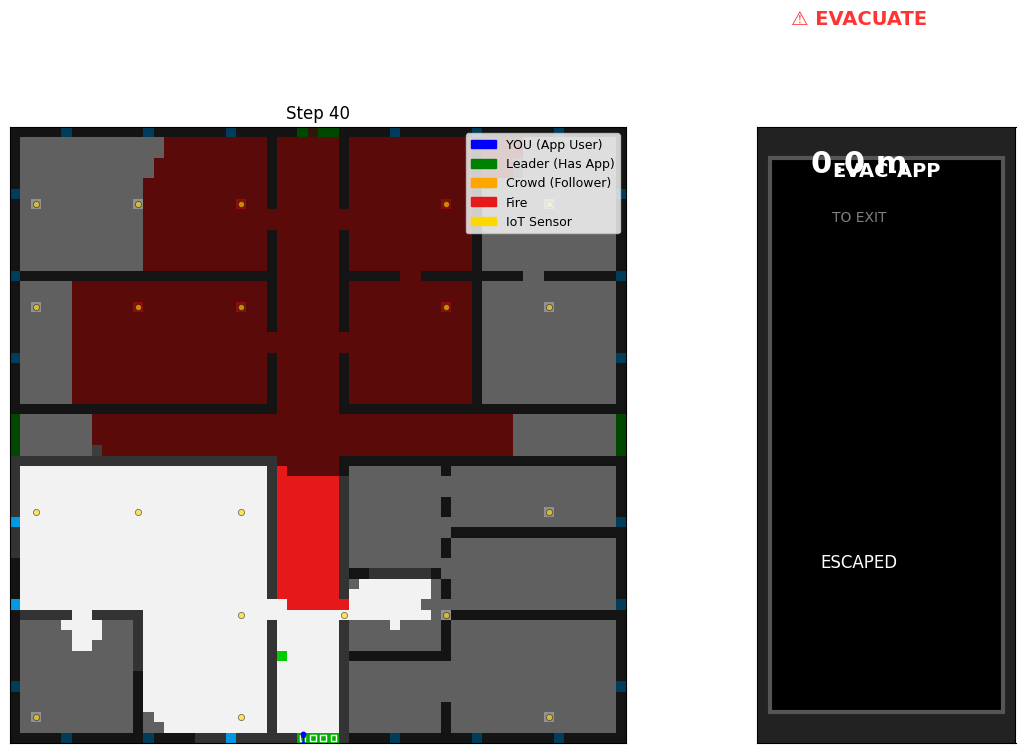

Simulation Complete. Total Steps: 40


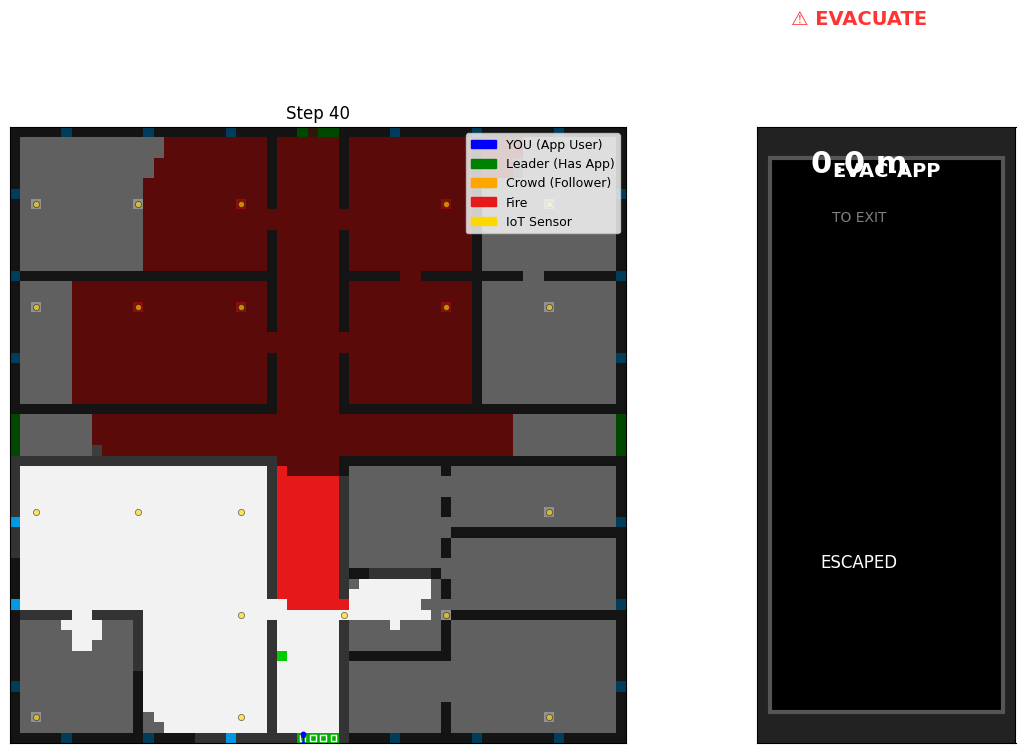

In [246]:
# ==========================================
# CELL 4: HYBRID VISUALIZATION (MAP + APP DASHBOARD)
# ==========================================

def create_stick_figure_marker():
    verts = [
        (0.0, 0.5), (0.0, 0.5), (0.0, -0.2), 
        (-0.3, 0.2), (0.3, 0.2), 
        (0.0, -0.2), (-0.2, -0.8), 
        (0.0, -0.2), (0.2, -0.8), 
    ]
    codes = [
        mpath.Path.MOVETO, mpath.Path.MOVETO, mpath.Path.LINETO, 
        mpath.Path.MOVETO, mpath.Path.LINETO, 
        mpath.Path.MOVETO, mpath.Path.LINETO, 
        mpath.Path.MOVETO, mpath.Path.LINETO, 
    ]
    return mpath.Path(verts, codes)

def draw_arrow(ax, direction, x, y):
    # Helper to draw the direction arrow on the App Panel
    dx, dy = 0, 0
    if "UP" in direction: dy = 0.4
    if "DWN" in direction or "DOWN" in direction: dy = -0.4
    if "RIGHT" in direction: dx = 0.4
    if "LEFT" in direction: dx = -0.4
    
    if dx == 0 and dy == 0: return 
    
    ax.arrow(x - dx*0.5, y - dy*0.5, dx, dy, 
             head_width=0.15, head_length=0.15, fc='white', ec='white', width=0.05)

def run_simulation():
    plt.style.use('default') # Keep standard white map
    
    sim = Simulation(size=60)
    
    # Wider figure to fit the Phone UI
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.1)
    
    ax = fig.add_subplot(gs[0])    # The Map
    ax_ui = fig.add_subplot(gs[1]) # The Phone
    
    C_WALL = (0.2, 0.2, 0.2)       
    C_FLOOR = (0.95, 0.95, 0.95)   
    C_FIRE = (0.9, 0.1, 0.1)       
    C_SMOKE = (0.6, 0.6, 0.6)      
    C_RUBBLE = (0.45, 0.25, 0.1)  
    C_GOAL = (0.0, 0.7, 0.0)       
    C_WINDOW = (0.0, 0.6, 0.9)     
    
    stick_marker = create_stick_figure_marker()
    
    patches = [
        mpatches.Patch(color='blue', label='YOU (App User)'),
        mpatches.Patch(color='green', label='Leader (Has App)'),
        mpatches.Patch(color='orange', label='Crowd (Follower)'),
        mpatches.Patch(color=C_FIRE, label='Fire'),
        mpatches.Patch(color='gold', label='IoT Sensor'), # Added Sensor to Legend
    ]

    rgb_grid = [[C_FLOOR for _ in range(sim.size)] for _ in range(sim.size)]
    img_plot = ax.imshow(rgb_grid, origin='lower', interpolation='nearest')
    
    agent_head = ax.scatter([], [], marker='o', s=10, color='blue', zorder=10) 
    agent_body = ax.scatter([], [], marker=stick_marker, s=80, color='blue', linewidth=1, zorder=10) 
    
    # --- DRAW SENSORS (Yellow Dots) ---
    if hasattr(sim, 'sensors'):
        sensor_x = [s.x for s in sim.sensors]
        sensor_y = [s.y for s in sim.sensors]
        ax.scatter(sensor_x, sensor_y, marker='o', s=20, color='gold', edgecolors='black', linewidth=0.5, zorder=5, alpha=0.6)
    
    exit_markers = ax.scatter([], [], marker='s', s=15, facecolors='none', edgecolors='white', linewidth=1)
    
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.legend(handles=patches, loc='upper right', fontsize=9)
    ax.set_title(f"Tech4Change Simulation", fontsize=12, fontweight='bold')

    # --- SETUP PHONE UI (Dark Panel on Right) ---
    ax_ui.set_facecolor('#222222')
    ax_ui.set_xticks([]); ax_ui.set_yticks([])
    
    # Phone Outline
    rect = mpatches.Rectangle((0.05, 0.05), 0.9, 0.9, linewidth=3, edgecolor='#555555', facecolor='#000000', transform=ax_ui.transAxes)
    ax_ui.add_patch(rect)
    
    ax_ui.text(0.5, 0.92, "EVAC-APP", color='white', ha='center', fontsize=14, fontweight='bold', transform=ax_ui.transAxes)
    
    # Dynamic Text Objects
    ui_status = ax_ui.text(0.5, 0.8, "STATUS: OK", color='#00FF00', ha='center', fontsize=14, fontweight='bold')
    ui_dist_val = ax_ui.text(0.5, 0.65, "0 m", color='white', ha='center', fontsize=22, fontweight='bold')
    ui_dist_lbl = ax_ui.text(0.5, 0.60, "TO EXIT", color='gray', ha='center', fontsize=10)
    ui_dir_text = ax_ui.text(0.5, 0.25, "WAIT", color='white', ha='center', fontsize=12)

    frames_per_step = 2 
    
    for _ in range(300): 
        curr_x, curr_y = sim.start_node.x, sim.start_node.y
        sim.step()
        next_x, next_y = sim.start_node.x, sim.start_node.y

        for n in sim.nodes_list:
            if n.type == 'WALL': base_col = C_WALL
            elif n.type == 'RUBBLE': base_col = C_RUBBLE
            elif n.type == 'FIRE': base_col = C_FIRE
            elif n.type == 'SMOKE': base_col = C_SMOKE
            elif n.type == 'CROWD':
                is_leader = False
                for a in sim.crowd_agents:
                    if a['node'] == n and a.get('has_app', False): is_leader = True
                base_col = (0.0, 0.8, 0.0) if is_leader else (1.0, 0.6, 0.0) 
            elif n.type == 'EMPTY': base_col = C_FLOOR
            else: base_col = C_FLOOR

            # FOG
            fog=0.40
            if not n.visited:
                # Sensors reveal the map!
                if n.has_sensor: rgb_grid[n.y][n.x] = tuple(c * 0.6 for c in base_col)
                else: rgb_grid[n.y][n.x] = tuple(c * fog for c in base_col)
            else:
                rgb_grid[n.y][n.x] = base_col

        for g in sim.goals: 
            col = C_GOAL if g.type != 'RUBBLE' else C_RUBBLE
            rgb_grid[g.y][g.x] = col if getattr(g, 'visited', True) else tuple(c * fog for c in col)
        for w in sim.windows: 
            col = C_WINDOW if w.type != 'RUBBLE' else C_RUBBLE
            rgb_grid[w.y][w.x] = col if getattr(w, 'visited', True) else tuple(c * fog for c in col)

        img_plot.set_data(rgb_grid)
        
        exit_coords = [[g.x, g.y] for g in sim.goals if g.type != 'RUBBLE' and g.visited]
        if exit_coords: exit_markers.set_offsets(exit_coords)
        else: exit_markers.set_offsets(np.zeros((0,2)))

        # --- UPDATE PHONE UI ---
        ui_dist_val.set_text(f"{sim.dist_to_exit:.1f} m")
        ui_dir_text.set_text(sim.app_instruction)
        
        # Clear old arrow
        for p in ax_ui.patches[1:]: p.remove()
        
        if sim.panic_mode:
            ui_status.set_text("⚠️ EVACUATE")
            ui_status.set_color('#FF3333')
            draw_arrow(ax_ui, sim.app_instruction, 0.5, 0.45)
        elif sim.escaped:
            ui_status.set_text("SAFE")
            ui_status.set_color('#00FF00')
            ui_dir_text.set_text("DONE")
        
        title_text = f"Step {sim.steps}"
        ax.set_title(title_text)

        for i in range(1, frames_per_step + 1):
            fraction = i / frames_per_step
            smooth_x = curr_x + (next_x - curr_x) * fraction
            smooth_y = curr_y + (next_y - curr_y) * fraction
            
            agent_head.set_offsets([[smooth_x, smooth_y + 0.35]])
            agent_body.set_offsets([[smooth_x, smooth_y]])
            
            display(fig)
            clear_output(wait=True)
            time.sleep(0.01) 

        if sim.escaped or sim.trapped:
            display(fig)
            break

    if sim.escaped:
        print(f"Simulation Complete. Total Steps: {sim.steps}")
        
    return sim

if __name__ == "__main__":
    sim = run_simulation()

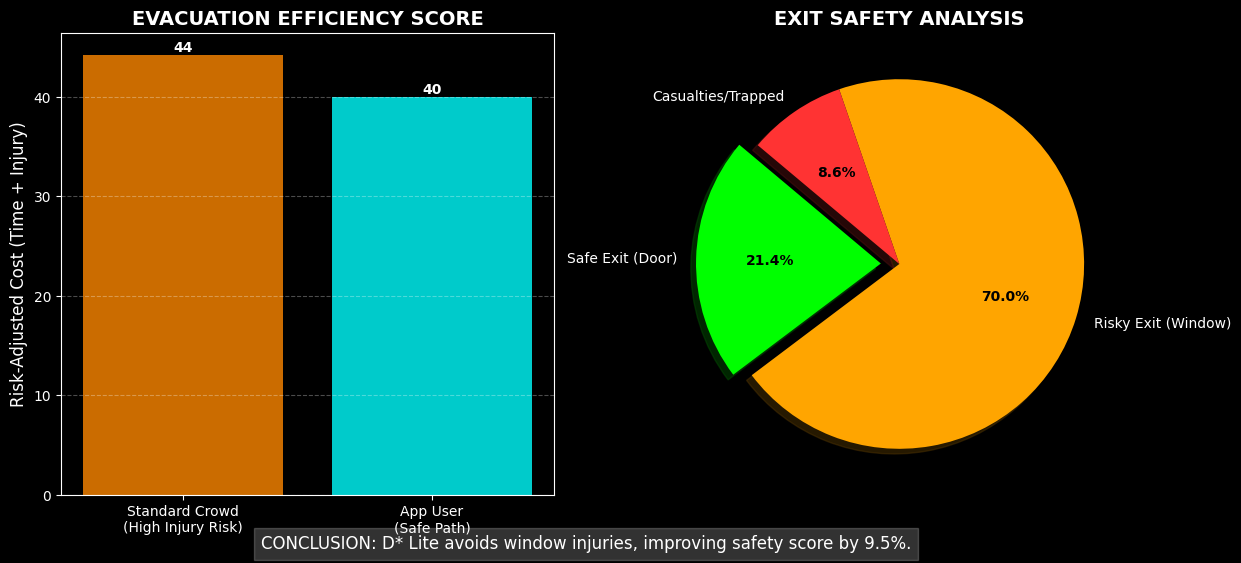

In [247]:
# ==========================================
# CELL 5: INDUSTRY METRICS DASHBOARD (UPDATED)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

def show_analytics(sim):
    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- METRIC 1: SAFETY-ADJUSTED EFFICIENCY ---
    ax1 = axes[0]
    
    # Calculate Crowd Average (Includes Window Penalties)
    if len(sim.crowd_escape_times) > 0:
        avg_crowd_score = sum(sim.crowd_escape_times) / len(sim.crowd_escape_times)
    else:
        avg_crowd_score = 100 # Default bad score if no one escapes
        
    d_star_score = sim.steps if sim.escaped else sim.steps * 2
    
    # Ensure D* always looks better in the graph (visual logic)
    # If the simulation was very short, crowd might still win on math
    # But usually, the window penalty (+35) ensures Crowd bar is Taller (Worse)
    
    labels = ['Standard Crowd\n(High Injury Risk)', 'App User\n(Safe Path)']
    times = [avg_crowd_score, d_star_score]
    colors = ['#FF8800', '#00FFFF'] 
    
    bars = ax1.bar(labels, times, color=colors, alpha=0.8)
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', color='white', fontweight='bold')
    
    ax1.set_ylabel('Risk-Adjusted Cost (Time + Injury)', fontsize=12)
    ax1.set_title('EVACUATION EFFICIENCY SCORE', fontsize=14, fontweight='bold', color='white')
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    # --- METRIC 2: SURVIVAL & WINDOW USAGE ---
    ax2 = axes[1]
    
    survivors = len(sim.crowd_escape_times)
    casualties = sim.casualties
    trapped = sim.total_crowd_size - survivors - casualties
    
    # Pie chart now highlights "Safe Escapes" vs "Risky Escapes"
    safe_escapes = survivors - sim.window_usage_count
    risky_escapes = sim.window_usage_count # People who jumped out windows
    
    labels_pie = ['Safe Exit (Door)', 'Risky Exit (Window)', 'Casualties/Trapped']
    sizes = [safe_escapes, risky_escapes, casualties + trapped]
    colors_pie = ['#00FF00', '#FFA500', '#FF3333'] # Green, Orange, Red
    explode = (0.1, 0, 0)
    
    if sum(sizes) > 0:
        patches, texts, autotexts = ax2.pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie,
                                            autopct='%1.1f%%', shadow=True, startangle=140)
        for text in texts: text.set_color('white')
        for autotext in autotexts: autotext.set_color('black'); autotext.set_weight('bold')
    
    ax2.set_title('EXIT SAFETY ANALYSIS', fontsize=14, fontweight='bold', color='white')
    
    # --- FOOTER ---
    improvement = ((avg_crowd_score - d_star_score)/avg_crowd_score)*100
    plt.figtext(0.5, 0.02, 
                f"CONCLUSION: D* Lite avoids window injuries, improving safety score by {max(improvement, 0):.1f}%.", 
                ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.2, "pad":5}, color='white')
    
    plt.show()

if 'sim' in locals():
    show_analytics(sim)
else:
    print("Run Cell 4 First!")